# 03 · Calidad y drift con Evidently

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


In [2]:
from bank_ops.monitor import scenario, drift_report
pool=validation.sample(frac=1,random_state=SEED)
reference=pool.iloc[:1500].copy();current=pool.iloc[1500:3000].copy()
shifted=scenario(current,"shift")
report=drift_report(reference,shifted,"notebook")
print("Reporte en reports/drift_notebook.html")

Reporte en reports/drift_notebook.html


## Magnitud y contexto
Lotes independientes de una misma validación. Balance y canal cambian artificialmente.

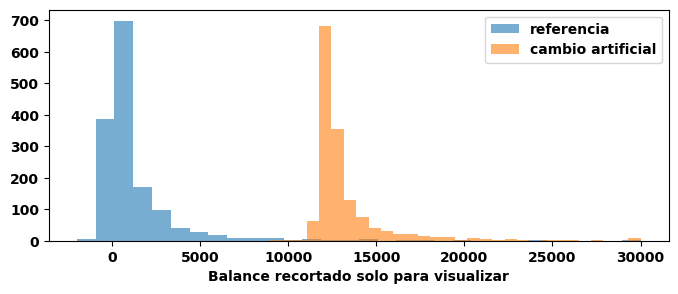

In [3]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,3))
ax.hist(reference.balance.clip(-2000,30000),bins=30,alpha=.6,label="referencia")
ax.hist(shifted.balance.clip(-2000,30000),bins=30,alpha=.6,label="cambio artificial")
ax.set_xlabel("Balance recortado solo para visualizar");ax.legend();plt.show()

In [4]:
from bank_ops.data import validate
try: validate(scenario(current,"invalid"))
except ValueError as error: print("Rechazo esperado:",error)
assert scenario(current,"degraded")[FEATURES].equals(current[FEATURES])

Rechazo esperado: campaign fuera del contrato


## Interpretación
Abrir HTML y revisar método, umbral, tamaño y columnas. ¿Por qué modificar etiquetas no es visible en las entradas? Proponer investigación antes de retraining.